# Biofluorescence image analysis for Hippocampus reidi

Run the cells from top to bottom. This notebook demonstrates the workflow using standardized seahorse images included in the repository.

Read README.md before adapting the workflow to another dataset.

## Initial configuration

In [31]:
from pathlib import Path

import hippocampus_reidi as hr

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

input_directory = project_root / "data" / "input"
output_directory = project_root / "data" / "output"

print(f"hippocampus-reidi version: {hr.__version__}")
print(f"Input directory: {input_directory}")
print(f"Output directory: {output_directory}")

hippocampus-reidi version: 0.1.0
Input directory: /home/brunopiato/personal/hippocampus_reidi/data/input
Output directory: /home/brunopiato/personal/hippocampus_reidi/data/output


## Optional color picker

Click pixels in the image to inspect their RGB values. This section is optional.

In [32]:
image_path = input_directory / "CM110.png"

In [33]:
%matplotlib widget
picked_colors = hr.pick_color_from_image_matplotlib(image_path=image_path)

In [34]:
picked_colors

[[36, 90, 1], [27, 67, 1]]

## Analyze one image

In [35]:
color_ranges = {
    # "green": ((0, 100, 0), (100, 255, 100)),
    # "red": ((100, 0, 0), (255, 100, 100)),
    "green_original": ((110, 172, 3), (110, 172, 3)),
    "green1": ((36, 90, 1), (36, 90, 1)),
    "green2": ((27, 67, 1), (27, 67, 1)),
    "green3": ((112, 184, 0), (112, 184, 0)),
    "green4": ((106, 180, 0), (106, 180, 0)),
    "green_range": ((0, 100, 0), (100, 255, 100)),
    "red_original": ((114,17,0), (114,17,0)),
    "blue": ((0, 35, 102), (204, 204, 255)),
}

## Patternize-style comparison

Use the RGB center and `col_offset` used in Patternize to compare the color-threshold result. This reproduces the color tolerance only; alignment, resampling, and outline-based area calculation still need to match separately.

In [36]:
patternize_rgb_colors = {
    "green": (110, 172, 3),
}

patternize_color_ranges = hr.make_patternize_color_ranges(
    patternize_rgb_colors,
    col_offset=0.10,
)

patternize_results = hr.analyze_image(
    image_path=image_path,
    color_ranges=patternize_color_ranges,
)
patternize_results

AttributeError: module 'hippocampus_reidi' has no attribute 'make_patternize_color_ranges'

In [26]:
single_image_results = hr.analyze_image(
    image_path=image_path,
    color_ranges=color_ranges,
)
single_image_results

{'image': 'CM110.png',
 'total_pixels': 2787328,
 'body_pixels': 736752,
 'background_pixels': 2050576,
 'background_percentage': 73.56780400440852,
 'colors': {'green0': {'lower': (110, 172, 3),
   'upper': (110, 172, 3),
   'pixels': 0,
   'percentage': 0.0},
  'green1': {'lower': (122, 176, 2),
   'upper': (122, 176, 2),
   'pixels': 0,
   'percentage': 0.0},
  'green2': {'lower': (51, 127, 5),
   'upper': (51, 127, 5),
   'pixels': 0,
   'percentage': 0.0},
  'green3': {'lower': (112, 184, 0),
   'upper': (112, 184, 0),
   'pixels': 0,
   'percentage': 0.0},
  'green4': {'lower': (106, 180, 0),
   'upper': (106, 180, 0),
   'pixels': 0,
   'percentage': 0.0},
  'green_range': {'lower': (0, 100, 0),
   'upper': (100, 255, 100),
   'pixels': 222,
   'percentage': 0.03013225617304059},
  'red': {'lower': (114, 17, 0),
   'upper': (114, 17, 0),
   'pixels': 0,
   'percentage': 0.0},
  'blue': {'lower': (0, 35, 102),
   'upper': (204, 204, 255),
   'pixels': 0,
   'percentage': 0.0}}}

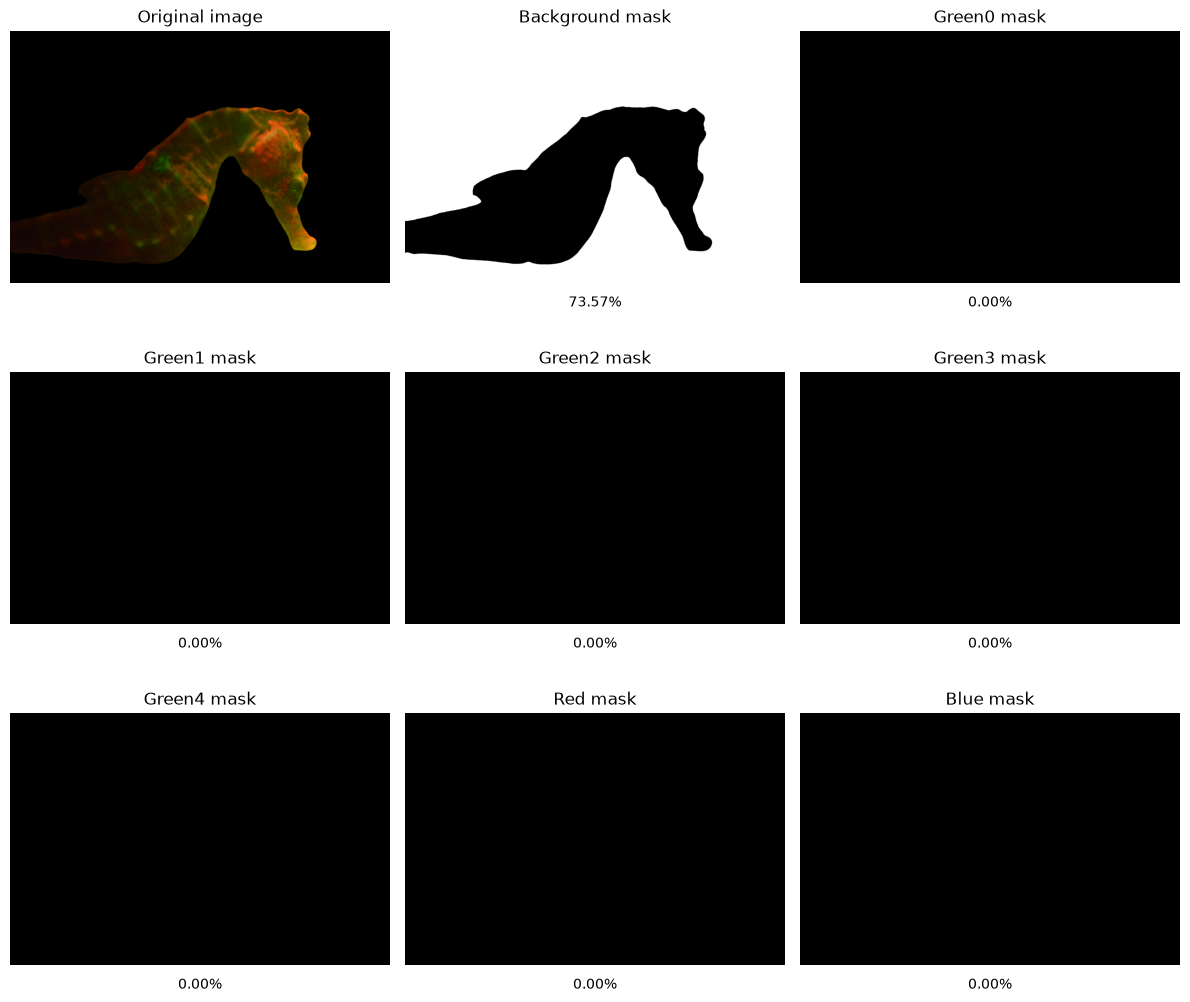

In [23]:
hr.plot_image_analysis(image_path, color_ranges)

## Analyze all images in the input folder

The CSV is saved to data/output/biofluorescence_results.csv.

In [24]:
folder_results = hr.analyze_folder(
    folder_path=input_directory,
    color_ranges=color_ranges,
    output_path=output_directory,
)
folder_results

[('CM110.png',
  {'image': 'CM110.png',
   'total_pixels': 2787328,
   'body_pixels': 736752,
   'background_pixels': 2050576,
   'background_percentage': 73.56780400440852,
   'colors': {'green0': {'lower': (110, 172, 3),
     'upper': (110, 172, 3),
     'pixels': 0,
     'percentage': 0.0},
    'green1': {'lower': (122, 176, 2),
     'upper': (122, 176, 2),
     'pixels': 0,
     'percentage': 0.0},
    'green2': {'lower': (51, 127, 5),
     'upper': (51, 127, 5),
     'pixels': 0,
     'percentage': 0.0},
    'green3': {'lower': (112, 184, 0),
     'upper': (112, 184, 0),
     'pixels': 0,
     'percentage': 0.0},
    'green4': {'lower': (106, 180, 0),
     'upper': (106, 180, 0),
     'pixels': 0,
     'percentage': 0.0},
    'red': {'lower': (114, 17, 0),
     'upper': (114, 17, 0),
     'pixels': 0,
     'percentage': 0.0},
    'blue': {'lower': (0, 35, 102),
     'upper': (204, 204, 255),
     'pixels': 0,
     'percentage': 0.0}}}),
 ('CM111.png',
  {'image': 'CM111.png',
   '